In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\chaud\Downloads\Agriculture_price_dataset.csv")
df.head(3)

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 737392 entries, 0 to 737391
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   STATE          737392 non-null  str    
 1   District Name  737392 non-null  str    
 2   Market Name    737392 non-null  str    
 3   Commodity      737392 non-null  str    
 4   Variety        737392 non-null  str    
 5   Grade          737392 non-null  str    
 6   Min_Price      737392 non-null  float64
 7   Max_Price      737392 non-null  float64
 8   Modal_Price    737392 non-null  float64
 9   Price Date     737392 non-null  str    
dtypes: float64(3), str(7)
memory usage: 93.0 MB


In [6]:
df.isnull().sum()

STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64

In [7]:

Q1 = df['Modal_Price'].quantile(0.25)
Q3 = df['Modal_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Modal_Price'] >= lower_bound) & (df['Modal_Price'] <= upper_bound)]

In [8]:
df = df.drop(['Min_Price', 'Max_Price'], axis=1)

In [9]:
df = df.sort_values('Price Date')

In [10]:
df['Lag_1'] = df['Modal_Price'].shift(1)
df['Lag_2'] = df['Modal_Price'].shift(2)
df['Lag_3'] = df['Modal_Price'].shift(3)


In [11]:
df['Date'] = pd.to_datetime(df['Price Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 702775 entries, 261850 to 472420
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   STATE          702775 non-null  str           
 1   District Name  702775 non-null  str           
 2   Market Name    702775 non-null  str           
 3   Commodity      702775 non-null  str           
 4   Variety        702775 non-null  str           
 5   Grade          702775 non-null  str           
 6   Modal_Price    702775 non-null  float64       
 7   Price Date     702775 non-null  str           
 8   Lag_1          702774 non-null  float64       
 9   Lag_2          702773 non-null  float64       
 10  Lag_3          702772 non-null  float64       
 11  Date           702775 non-null  datetime64[us]
 12  Year           702775 non-null  int32         
 13  Month          702775 non-null  int32         
dtypes: datetime64[us](1), float64(4), int32(2), str(7)
memory usage

In [13]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
le = LabelEncoder()
df['Commodity'] = le.fit_transform(df['Commodity'])
df['STATE'] = le.fit_transform(df['STATE'])
df['Market Name'] = le.fit_transform(df['Market Name'])

In [14]:
X = df[['Commodity', 'STATE', 'Market Name', 'Year', 'Month']]
y = df['Modal_Price']   

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
r2 = r2_score(y_test, y_pred_rf)
print("R2 Score:", r2)

RF MAE: 181.69624004123594
RF RMSE: 337.3515234366275
R2 Score: 0.9146763994955638


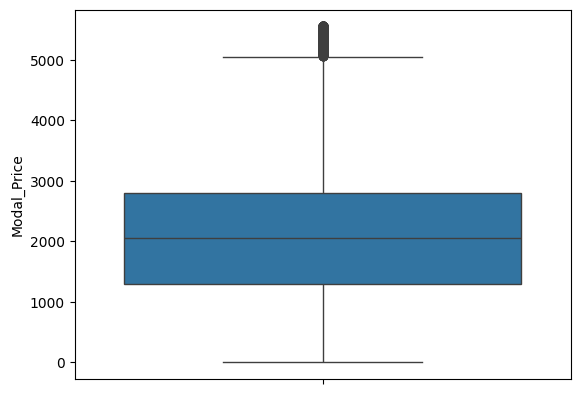

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df['Modal_Price'])
plt.show()

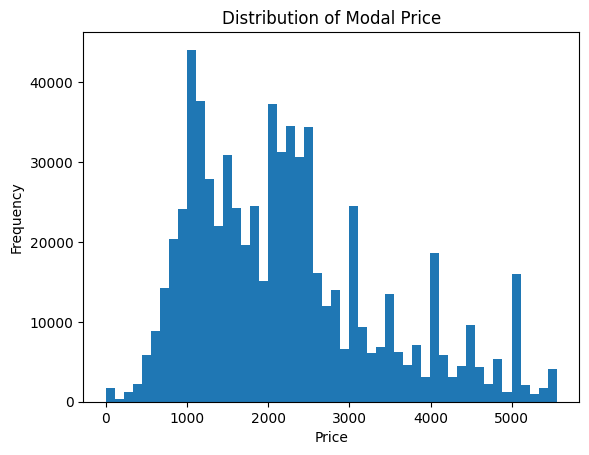

In [19]:
plt.figure()
plt.hist(df['Modal_Price'], bins=50)
plt.title("Distribution of Modal Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

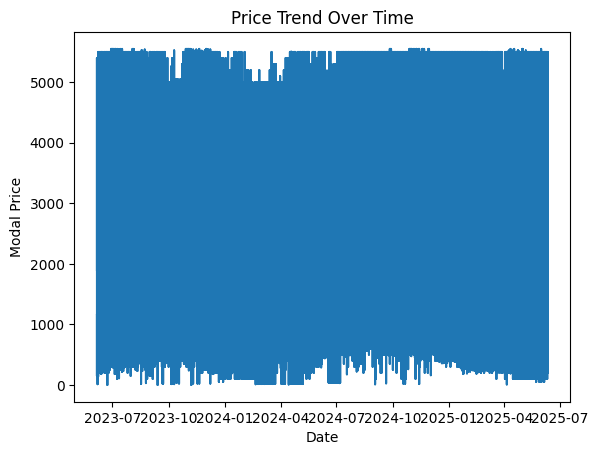

In [20]:
plt.figure()
df_sorted = df.sort_values('Date')
plt.plot(df_sorted['Date'], df_sorted['Modal_Price'])
plt.title("Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Modal Price")
plt.show()

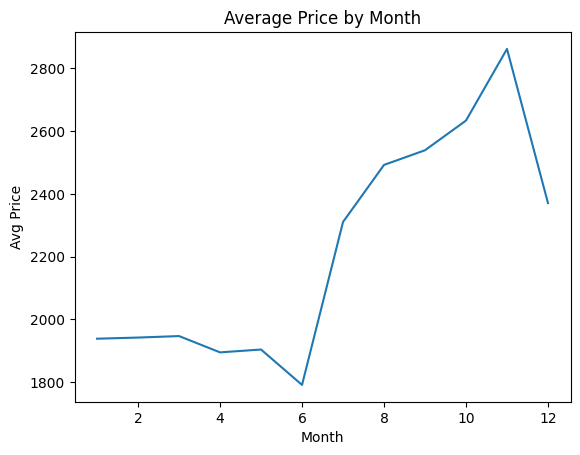

In [21]:
monthly_avg = df.groupby('Month')['Modal_Price'].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values)
plt.title("Average Price by Month")
plt.xlabel("Month")
plt.ylabel("Avg Price")
plt.show()

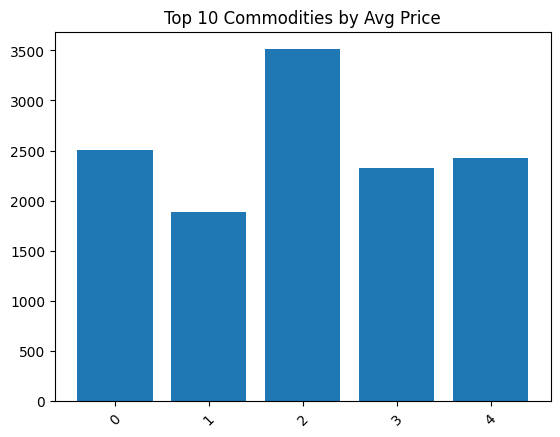

In [22]:
top_commodities = df.groupby('Commodity')['Modal_Price'].mean().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_commodities.index, top_commodities.values)
plt.title("Top 10 Commodities by Avg Price")
plt.xticks(rotation=45)
plt.show()

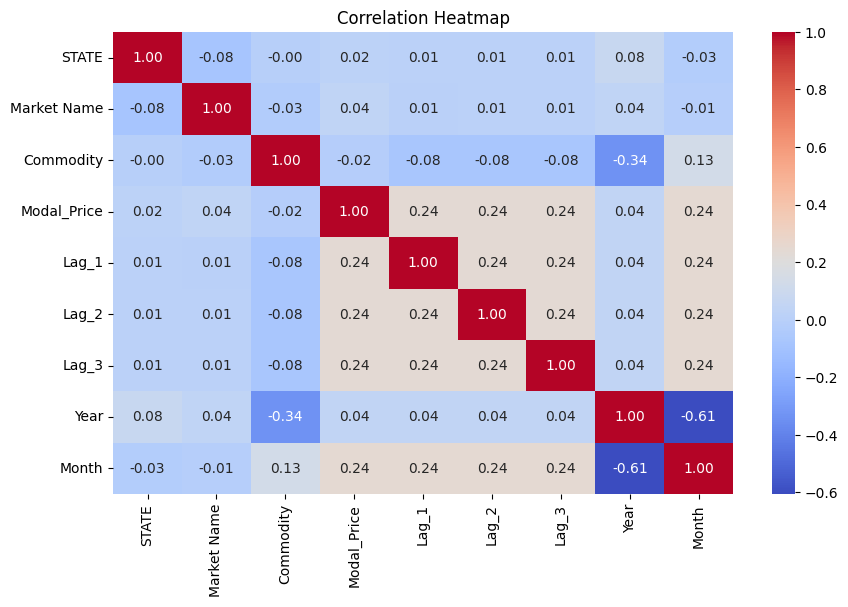

In [23]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [27]:
import pickle

with open("crop_price_model.pkl", "wb") as f:
    pickle.dump(rf, f)
print("model saved" )

model saved
